# NAF (Normalized Advangate Function)
이 튜토리얼은 `**NAF (Normalized Advantage Function)** 알고리즘을 구현하는 방법을 안내한다.

**NAF (Normalized Advantage Function)**는 DQN을 연속적인 행동 공간(Continuous Action Space)에 적용할 수 있도록 확장한 알고리즘이다. Q 함수를 $Q(s, a) = V(s) + A(s, a)$로 분해하고, )을 쉽게 찾을 수 있게 만든 구조다.

이 튜토리얼에서는 최신 라이브러리인 `gymnasium`과 `torch`를 기준으로 코드를 리팩토링하였으며, 환경은 `LunarLanderContinuous-v2`를 사용한다.

### 1. 가상 디스플레이 설정 (Setup virtual display)

강화학습 환경의 렌더링을 위해 가상 디스플레이를 설정한다.

In [ ]:
# 최신 파이썬 라이브러리 설치 (gym -> gymnasium)
%pip install gymnasium[box2d] pyvirtualdisplay torch numpy matplotlib imageio

In [16]:
from pyvirtualdisplay import Display

# 가상 디스플레이 시작
virtual_display = Display(visible=False, size=(1400, 900))
virtual_display.start()

### 2. 라이브러리 임포트 (Import libraries)

학습에 필요한 라이브러리를 불러온다.

In [17]:
import copy
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from collections import deque
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import HTML
from base64 import b64encode
import imageio

# GPU 사용 가능 여부 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 장치: {device}")

사용 장치: cuda


### 3. 비디오 출력 함수 (Display Video)

학습 결과를 영상으로 확인하기 위한 함수다.

In [18]:
def display_video(video_path):
    """
    저장된 mp4 비디오 파일을 읽어 HTML 태그로 변환하여 출력한다.
    """
    mp4 = open(video_path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML("""
    <video width=400 controls>
          <source src="%s" type="video/mp4">
    </video>
    """ % data_url)

### 4. NAF 신경망 모델 생성 (Create NAF Deep Q-Network)

NAF의 핵심인 신경망 구조를 정의한다. NAF는 Q값을 다음과 같이 정의한다:



여기서 로 정의하여 항상 양의 정부호(Positive Definite)가 되도록 함으로써, $A(s, a)$가 항상 0 이하가 되게 만든다. 따라서 $\mu(s)$가 최적의 행동이 된다.

In [19]:
class NafDQN(nn.Module):
    def __init__(self, hidden_size, obs_size, action_dims, max_action):
        """
        NAF 네트워크 초기화
        :param obs_size: 관측 상태 크기
        :param action_dims: 행동 차원 크기
        :param max_action: 행동의 최대 크기 (스케일링용)
        """
        super().__init__()
        self.action_dims = action_dims
        self.max_action = torch.from_numpy(max_action).to(device)

        # 공통 특징 추출 레이어
        self.net = nn.Sequential(
            nn.Linear(obs_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
        )

        # Mu(s): 최적 행동을 예측하는 레이어
        self.linear_mu = nn.Linear(hidden_size, action_dims)

        # V(s): 상태 가치를 예측하는 레이어
        self.linear_value = nn.Linear(hidden_size, 1)

        # L(s): Advantage 함수의 곡률(행렬 P)을 결정하는 레이어
        # 하삼각 행렬(Lower Triangular Matrix)의 원소들을 출력함
        self.linear_matrix = nn.Linear(hidden_size, int(action_dims * (action_dims + 1) / 2))

    @torch.no_grad()
    def mu(self, x):
        """최적 행동(Mu) 반환 (테스트 시 사용)"""
        x = self.net(x)
        x = self.linear_mu(x)
        # tanh로 -1~1 사이로 만들고 max_action으로 스케일링
        x = torch.tanh(x) * self.max_action
        return x

    @torch.no_grad()
    def value(self, x):
        """상태 가치 V(s) 반환 (타겟 계산 시 사용)"""
        x = self.net(x)
        x = self.linear_value(x)
        return x

    def forward(self, x, a):
        """Q(s, a) 계산 (학습 시 사용)"""
        x = self.net(x)

        mu = torch.tanh(self.linear_mu(x)) * self.max_action
        value = self.linear_value(x)

        # L 행렬 구성
        matrix = torch.tanh(self.linear_matrix(x))
        L = torch.zeros((x.shape[0], self.action_dims, self.action_dims)).to(device)

        # 하삼각 행렬 인덱스 가져오기
        tril_indices = torch.tril_indices(row=self.action_dims, col=self.action_dims, offset=0).to(device)
        L[:, tril_indices[0], tril_indices[1]] = matrix

        # 대각 성분은 지수함수를 취해 양수로 만듦 (Positive Definite 보장)
        L.diagonal(dim1=1, dim2=2).exp_()

        # P = L * L^T
        P = L @ L.transpose(2, 1)

        # Advantage 계산: A = -0.5 * (a - mu)^T * P * (a - mu)
        u_mu = (a - mu).unsqueeze(dim=1) # (Batch, 1, Action)
        u_mu_t = u_mu.transpose(1, 2)    # (Batch, Action, 1)

        adv = -0.5 * u_mu @ P @ u_mu_t
        adv = adv.squeeze(dim=-1) # (Batch, 1)

        # Q = V + A
        return value + adv

### 5. 경험 리플레이 버퍼 (Replay Buffer)

연속 행동 공간에서도 동일하게 사용되는 리플레이 버퍼다.

In [20]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def __len__(self):
        return len(self.buffer)

    def append(self, experience):
        self.buffer.append(experience)

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

### 6. Pytorch Wrapper 클래스 (NAF 알고리즘 구현)

NAF 알고리즘의 학습 루프와 타겟 업데이트 로직을 포함한다.

* **행동 선택**: `mu(s)`에 노이즈를 더하여 탐험을 수행한다.
* **타겟 계산**:
* 일반 DQN은 $\max_a Q(s', a)$를 구해야 하지만, NAF에서는 의 최대값이 $V(s')$이므로 계산이 매우 간단하다.


* **Soft Update**: 타겟 네트워크를 천천히 업데이트하는 Polyak Averaging을 사용한다.

In [21]:
class PytorchWrapper:
    def __init__(self, env_name, hidden_size=256, lr=1e-3, capacity=100000,
                 gamma=0.99, batch_size=128, tau=0.005):
        self.env_name = env_name
        self.gamma = gamma
        self.batch_size = batch_size
        self.tau = tau # 타겟 네트워크 소프트 업데이트 비율

        # 환경 생성 (Continuous)
        self.env = gym.make(env_name, render_mode='rgb_array')
        obs_size = self.env.observation_space.shape[0]
        action_dims = self.env.action_space.shape[0]
        max_action = self.env.action_space.high

        # 네트워크 초기화
        self.q_net = NafDQN(hidden_size, obs_size, action_dims, max_action).to(device)
        self.target_q_net = copy.deepcopy(self.q_net).to(device)

        self.optimizer = optim.AdamW(self.q_net.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss() # NAF는 주로 MSE 사용

        self.buffer = ReplayBuffer(capacity)

    def get_action(self, state, epsilon):
        """
        Noisy Policy: Mu(s) + Noise
        """
        # state를 (1, obs_size) 형태로 변환 (unsqueeze(0)는 한 번만 수행)
        state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)

        with torch.no_grad():
            mu = self.q_net.mu(state_t) # 출력 shape: (1, action_dims)

        # 노이즈 추가
        noise = torch.randn_like(mu) * epsilon
        action = mu + noise

        # 행동 범위 클램핑
        amin = torch.from_numpy(self.env.action_space.low).to(device)
        amax = torch.from_numpy(self.env.action_space.high).to(device)
        action = action.clamp(amin, amax)

        # .squeeze()를 사용해 (1, action_dims) -> (action_dims,)로 변환하여 1차원 배열로 반환
        return action.cpu().numpy().squeeze()

    def soft_update(self, net, target_net):
        """Polyak Averaging을 이용한 타겟 네트워크 업데이트"""
        for param, target_param in zip(net.parameters(), target_net.parameters()):
            target_param.data.copy_(self.tau * param.data + (1 - self.tau) * target_param.data)

    def train_step(self):
        if len(self.buffer) < self.batch_size:
            return 0.0

        batch = self.buffer.sample(self.batch_size)
        states, actions, rewards, dones, next_states = zip(*batch)

        states = torch.tensor(np.array(states), dtype=torch.float32, device=device)
        actions = torch.tensor(np.array(actions), dtype=torch.float32, device=device)
        rewards = torch.tensor(rewards, dtype=torch.float32, device=device).unsqueeze(1)
        dones = torch.tensor(dones, dtype=torch.float32, device=device).unsqueeze(1)
        next_states = torch.tensor(np.array(next_states), dtype=torch.float32, device=device)

        # 1. 현재 Q값 계산: Q(s, a)
        # NAF 구조상 a를 입력으로 받아야 함
        current_q = self.q_net(states, actions)

        # 2. 타겟 Q값 계산
        # NAF의 장점: max_a Q(s', a) = V(s')
        # 따라서 별도의 최적화 없이 V(s')만 가져오면 됨
        with torch.no_grad():
            next_v = self.target_q_net.value(next_states)
            target_q = rewards + (1 - dones) * self.gamma * next_v

        # 3. 손실 계산 및 업데이트
        loss = self.loss_fn(current_q, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # 4. 타겟 네트워크 소프트 업데이트
        self.soft_update(self.q_net, self.target_q_net)

        return loss.item()

    def run_training(self, max_episodes=600, max_steps=1000):
        total_rewards = []

        for episode in range(max_episodes):
            state, _ = self.env.reset()
            episode_reward = 0

            # 탐험 노이즈 크기 조절
            epsilon = max(0.1, 1.0 - (episode / 200))

            for step in range(max_steps):
                action = self.get_action(state, epsilon)
                next_state, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated

                self.buffer.append((state, action, reward, done, next_state))
                state = next_state
                episode_reward += reward

                self.train_step()

                if done:
                    break

            total_rewards.append(episode_reward)

            if episode % 10 == 0:
                print(f"Episode {episode}, Reward: {episode_reward:.2f}, Epsilon: {epsilon:.2f}")

        return total_rewards

    def save_video(self, filename="naf_dqn_video"):
        env = gym.make(self.env_name, render_mode='rgb_array')
        env = gym.wrappers.RecordVideo(env, video_folder="videos", name_prefix=filename)

        state, _ = env.reset()
        done = False
        while not done:
            # 테스트 시에는 노이즈 없이(epsilon=0) 최적 행동 선택
            action = self.get_action(state, epsilon=0.0)
            state, _, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
        env.close()

### 7. 학습 실행 (Training)

NAF 에이전트를 생성하고 연속 행동 공간인 `LunarLanderContinuous-v2` 환경에서 학습을 시작한다.

In [22]:
# 모델 생성
agent = PytorchWrapper('LunarLanderContinuous-v3', hidden_size=256, lr=1e-3)

# 학습 시작
print("NAF (Normalized Advantage Function) 학습을 시작한다...")
history = agent.run_training(max_episodes=200) # 학습 시간이 오래 걸릴 수 있음
print("학습 완료.")

NAF (Normalized Advantage Function) 학습을 시작한다...
Episode 0, Reward: -237.81, Epsilon: 1.00
Episode 10, Reward: -433.79, Epsilon: 0.95
Episode 20, Reward: -70.97, Epsilon: 0.90
Episode 30, Reward: -5.21, Epsilon: 0.85
Episode 40, Reward: -24.90, Epsilon: 0.80
Episode 50, Reward: 94.58, Epsilon: 0.75
Episode 60, Reward: -129.46, Epsilon: 0.70
Episode 70, Reward: -132.40, Epsilon: 0.65
Episode 80, Reward: 152.11, Epsilon: 0.60
Episode 100, Reward: 137.19, Epsilon: 0.50
Episode 110, Reward: 135.94, Epsilon: 0.45
Episode 120, Reward: -28.16, Epsilon: 0.40
Episode 130, Reward: 236.88, Epsilon: 0.35
Episode 140, Reward: 238.10, Epsilon: 0.30
Episode 150, Reward: 273.67, Epsilon: 0.25
Episode 160, Reward: 284.04, Epsilon: 0.20
Episode 170, Reward: 254.56, Epsilon: 0.15
Episode 180, Reward: 248.35, Epsilon: 0.10
Episode 190, Reward: 271.64, Epsilon: 0.10
학습 완료.


### 8. 결과 시각화 (Visualization)

학습 결과를 그래프와 비디오로 확인한다.

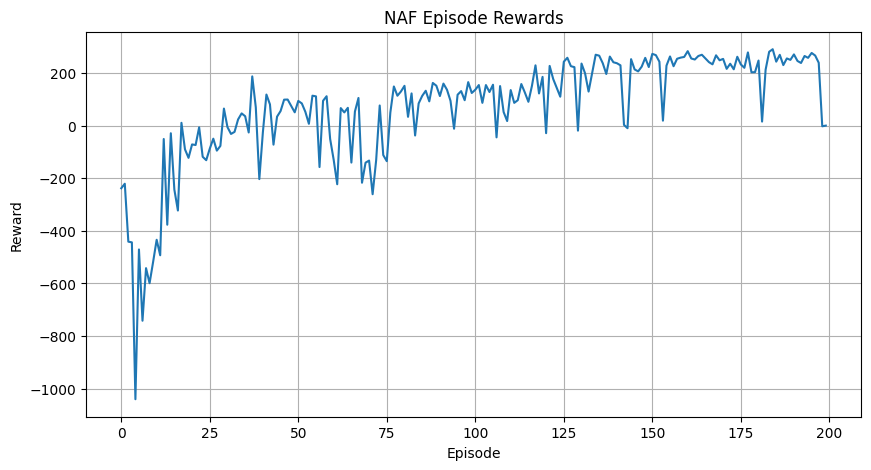

/home/kubwa/anaconda3/envs/RL/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/kubwa/02-Deep-RL/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [23]:
# 학습 곡선
plt.figure(figsize=(10, 5))
plt.plot(history)
plt.title("NAF Episode Rewards")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

# 비디오 저장 및 확인
import glob
import os

agent.save_video("naf-dqn")

# 가장 최근 비디오 파일 찾기
video_files = glob.glob("videos/*.mp4")
if video_files:
    latest_video = max(video_files, key=os.path.getctime)
    display(display_video(latest_video))
else:
    print("비디오 파일을 찾을 수 없다.")